In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("adult.data",header=None)

In [4]:
names=["age","workclass","fnlwgt","education","education-num","marital-status","occupation","relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country","class"]

In [5]:
df.columns=names

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  class           32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe(include="all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [9]:
df[df.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [10]:
df=df.drop_duplicates()

In [11]:
df.shape

(32537, 15)

In [12]:
df["class"]=df["class"].replace(" <=50K","-1")

In [13]:
df["class"]=df["class"].replace(" >50K","1")

In [14]:
df["class"].unique()

array(['-1', '1'], dtype=object)

In [15]:
import ydata_profiling

In [16]:
profile=df.profile_report()

In [17]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
df["class"].value_counts()

-1    24698
1      7839
Name: class, dtype: int64

In [19]:
df["class"].value_counts(normalize=True)*100

-1    75.907428
1     24.092572
Name: class, dtype: float64

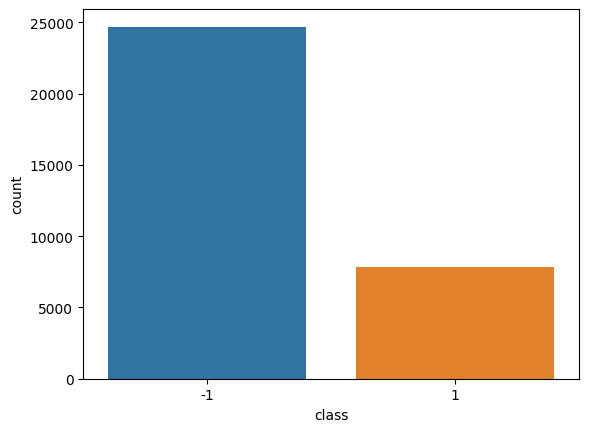

In [20]:
sns.countplot(x=df["class"])
plt.show()

In [21]:
capital_gain=df[df["capital-gain"]>0]

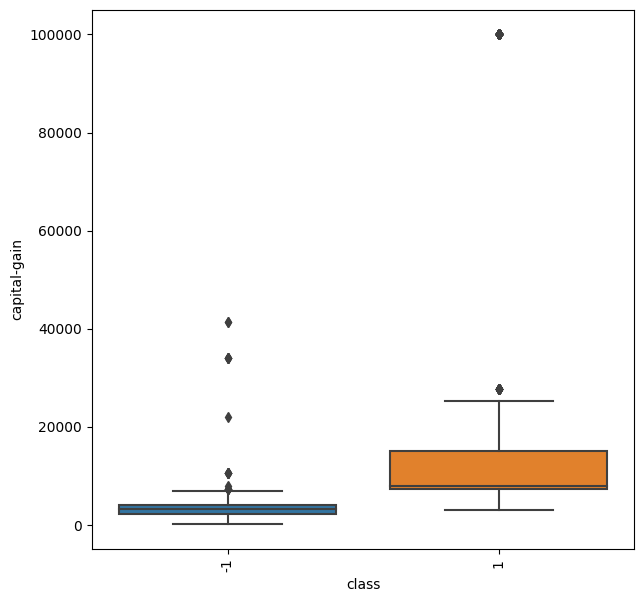

In [22]:
plt.figure(figsize=(7,7))
plt.xticks(rotation = 90)
sns.boxplot(x='class',y='capital-gain',data=capital_gain)
plt.show()

In [23]:
capital_loss=df[df["capital-loss"]>0]

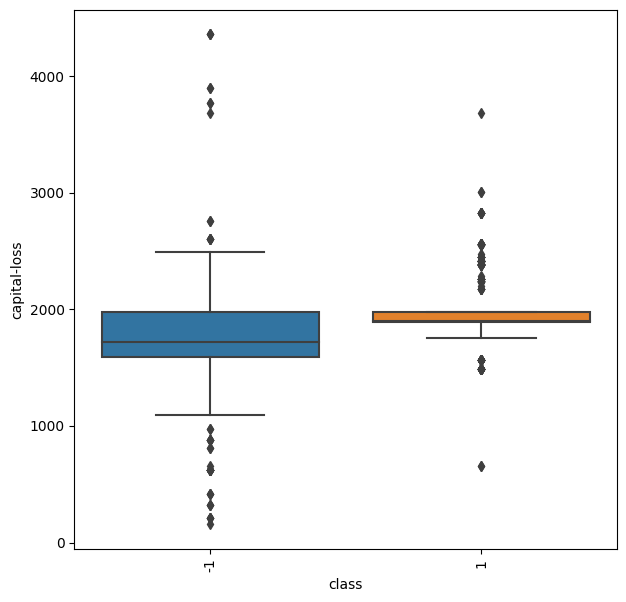

In [24]:
plt.figure(figsize=(7,7))
plt.xticks(rotation = 90)
sns.boxplot(x='class',y='capital-loss',data=capital_loss)
plt.show()

In [25]:
capital_gain.groupby(["class"])["capital-gain"].count()

class
-1    1035
1     1677
Name: capital-gain, dtype: int64

In [26]:
capital_gain["capital-gain"].unique()

array([ 2174, 14084,  5178,  5013,  2407, 14344, 15024,  7688, 34095,
        4064,  4386,  7298,  1409,  3674,  1055,  3464,  2050,  2176,
         594, 20051,  6849,  4101,  1111,  8614,  3411,  2597, 25236,
        4650,  9386,  2463,  3103, 10605,  2964,  3325,  2580,  3471,
        4865, 99999,  6514,  1471,  2329,  2105,  2885, 25124, 10520,
        2202,  2961, 27828,  6767,  2228,  1506, 13550,  2635,  5556,
        4787,  3781,  3137,  3818,  3942,   914,   401,  2829,  2977,
        4934,  2062,  2354,  5455, 15020,  1424,  3273, 22040,  4416,
        3908, 10566,   991,  4931,  1086,  7430,  6497,   114,  7896,
        2346,  3418,  3432,  2907,  1151,  2414,  2290, 15831, 41310,
        4508,  2538,  3456,  6418,  1848,  3887,  5721,  9562,  1455,
        2036,  1831, 11678,  2936,  2993,  7443,  6360,  1797,  1173,
        4687,  6723,  2009,  6097,  2653,  1639, 18481,  7978,  2387,
        5060])

In [27]:
cat=[]
for i in capital_gain["capital-gain"]:
    if i<5000:
        cat.append("Low")
    elif i < 10000:
        cat.append("Medium")
    else:
        cat.append("High")

In [28]:
capital_gain["capital_class"]=cat

<AxesSubplot: xlabel='capital_class', ylabel='count'>

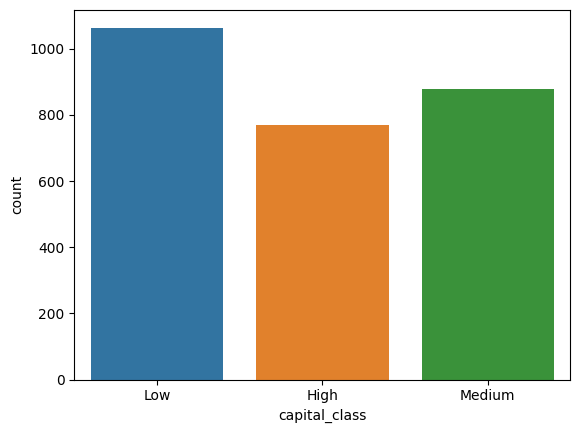

In [29]:
sns.countplot(x=capital_gain["capital_class"])

In [30]:
capital_gain_1=capital_gain[capital_gain["class"]=="1"]

<AxesSubplot: xlabel='capital_class', ylabel='count'>

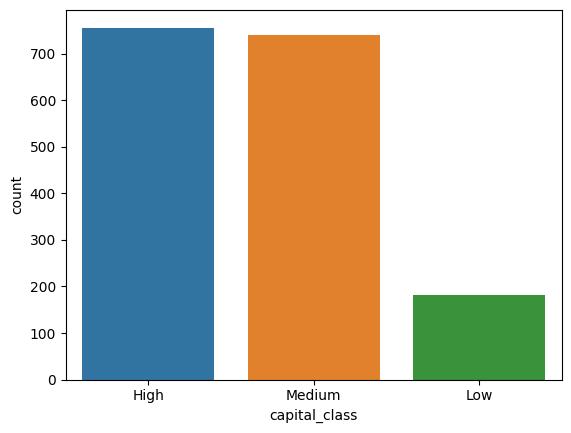

In [31]:
sns.countplot(x=capital_gain_1["capital_class"])

In [32]:
capital_gain_2=capital_gain[capital_gain["class"]=="-1"]

<AxesSubplot: xlabel='capital_class', ylabel='count'>

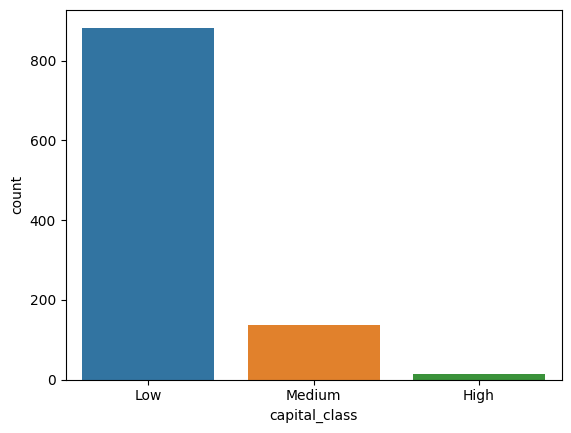

In [33]:
sns.countplot(x=capital_gain_2["capital_class"])

In [34]:
cat=[]
for i in capital_loss["capital-loss"]:
    if i<5000:
        cat.append("Low")
    elif i < 10000:
        cat.append("Medium")
    else:
        cat.append("High")

In [35]:
capital_loss["capital_class"]=cat

<AxesSubplot: xlabel='capital_class', ylabel='count'>

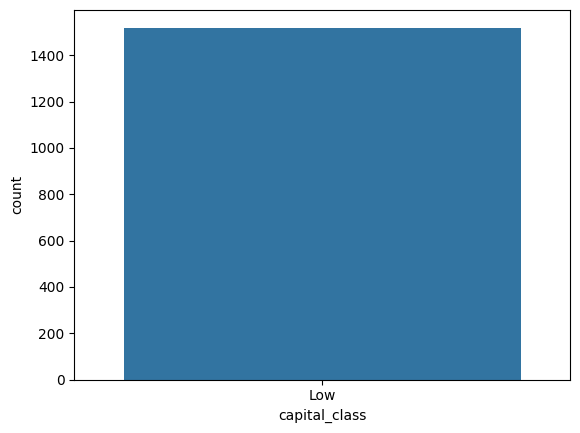

In [36]:
sns.countplot(x=capital_loss["capital_class"])

In [37]:
df["age"].describe()

count    32537.000000
mean        38.585549
std         13.637984
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

<AxesSubplot: >

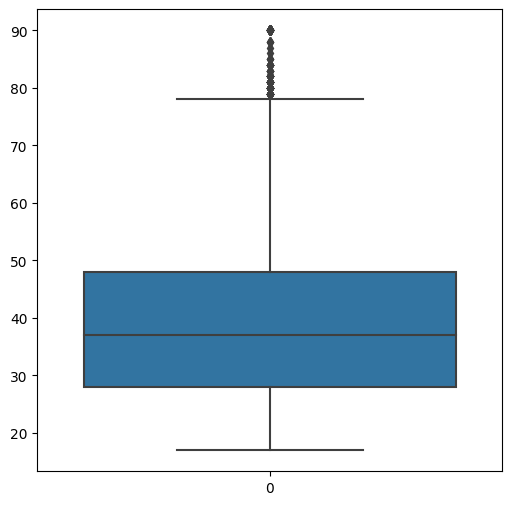

In [38]:
plt.figure(figsize=(6,6))
sns.boxplot(df["age"])

<AxesSubplot: xlabel='age', ylabel='Count'>

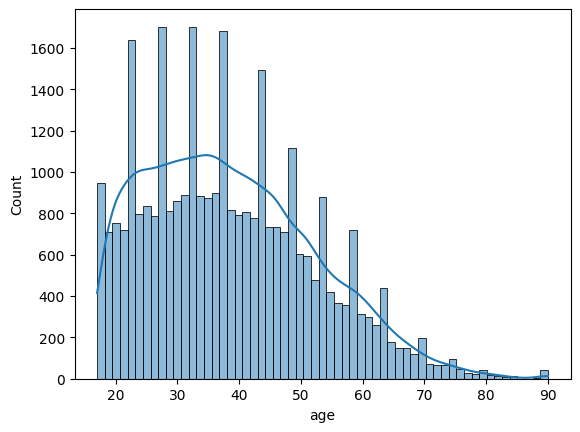

In [39]:
sns.histplot(df["age"],kde=True)

In [40]:
class_1=df[df["class"]=="1"]

<AxesSubplot: xlabel='age', ylabel='Count'>

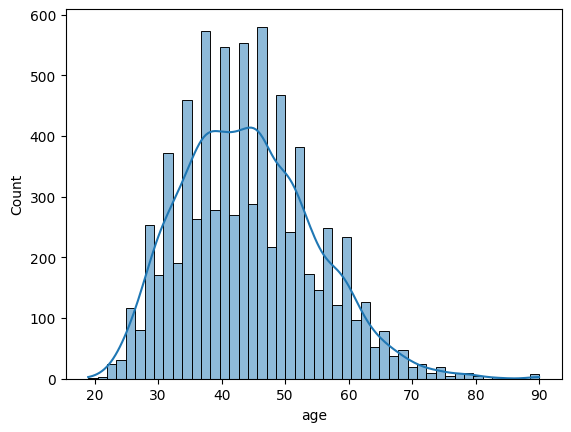

In [41]:
sns.histplot(class_1["age"],kde=True)

In [42]:
class_2=df[df["class"]=="-1"]

<AxesSubplot: xlabel='age', ylabel='Count'>

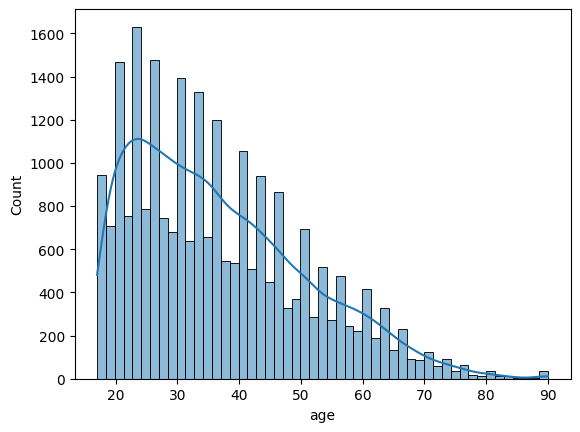

In [43]:
sns.histplot(class_2["age"],kde=True)

<AxesSubplot: xlabel='age', ylabel='class'>

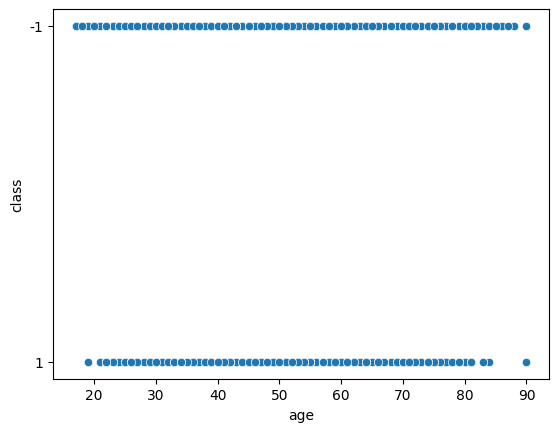

In [44]:
sns.scatterplot(x="age",y="class",data=df)

In [45]:
group=df.groupby(["sex","age"])["hours-per-week"].mean().reset_index()

<AxesSubplot: xlabel='age', ylabel='hours-per-week'>

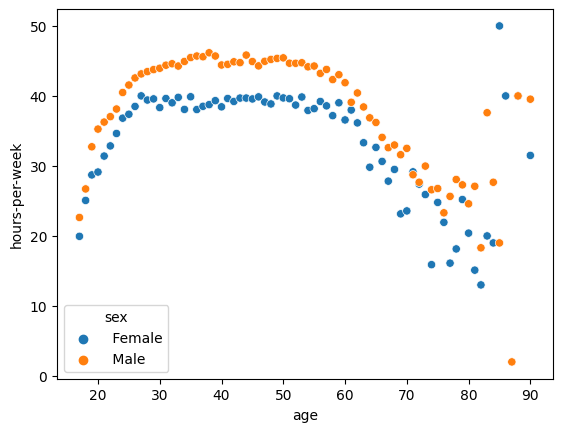

In [46]:
sns.scatterplot(x="age",y="hours-per-week",hue="sex",data=group)

In [47]:
capital_loss["capital-loss"].unique()

array([2042, 1408, 1902, 1573, 1887, 1719, 1762, 1564, 2179, 1816, 1980,
       1977, 1876, 1340, 2206, 1741, 1485, 2339, 2415, 1380, 1721, 2051,
       2377, 1669, 2352, 1672,  653, 2392, 1504, 2001, 1590, 1651, 1628,
       1848, 1740, 2002, 1579, 2258, 1602,  419, 2547, 2174, 2205, 1726,
       2444, 1138, 2238,  625,  213, 1539,  880, 1668, 1092, 1594, 3004,
       2231, 1844,  810, 2824, 2559, 2057, 1974,  974, 2149, 1825, 1735,
       1258, 2129, 2603, 2282,  323, 4356, 2246, 1617, 1648, 2489, 3770,
       1755, 3683, 2267, 2080, 2457,  155, 3900, 2201, 1944, 2467, 2163,
       2754, 2472, 1411])

In [48]:
df["native-country"]=df["native-country"].str.replace("?","unknown")

In [49]:
country=df["native-country"].value_counts()[:10].sort_values(ascending=False).reset_index()

In [50]:
col=["country","count"]

In [51]:
country.columns=col

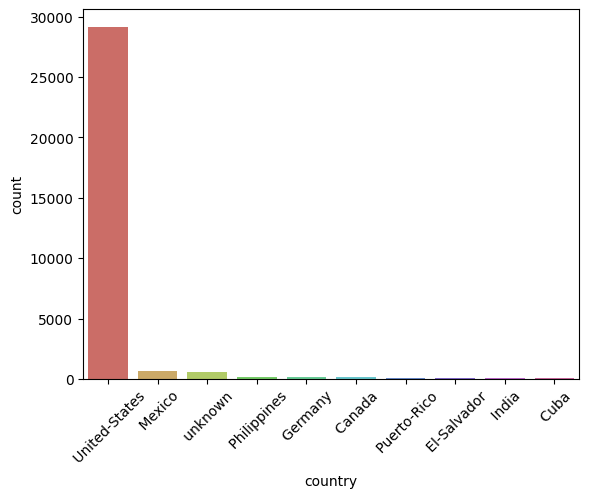

In [52]:
sns.barplot(x="country",y="count",data=country,palette="hls")
plt.xticks(rotation=45)
plt.show()

In [53]:
df["occupation"].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [54]:
df["occupation"].value_counts(normalize=True)*100

 Prof-specialty       12.711682
 Craft-repair         12.582598
 Exec-managerial      12.493469
 Adm-clerical         11.580662
 Sales                11.217998
 Other-service        10.114639
 Machine-op-inspct     6.146848
 ?                     5.664321
 Transport-moving      4.908258
 Handlers-cleaners     4.207518
 Farming-fishing       3.048837
 Tech-support          2.849064
 Protective-serv       1.994652
 Priv-house-serv       0.451793
 Armed-Forces          0.027661
Name: occupation, dtype: float64

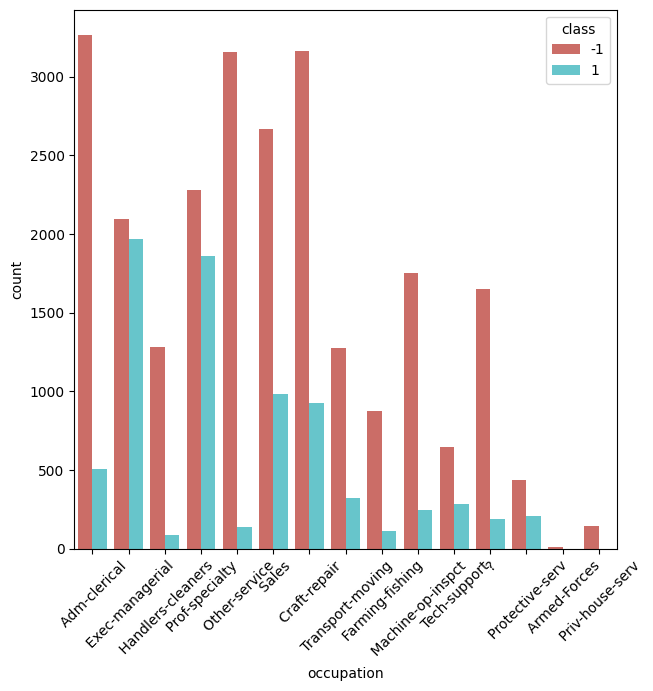

In [55]:
plt.figure(figsize=(7,7))
sns.countplot(x="occupation",hue="class",data=df,palette="hls")
plt.xticks(rotation=45)
plt.show()

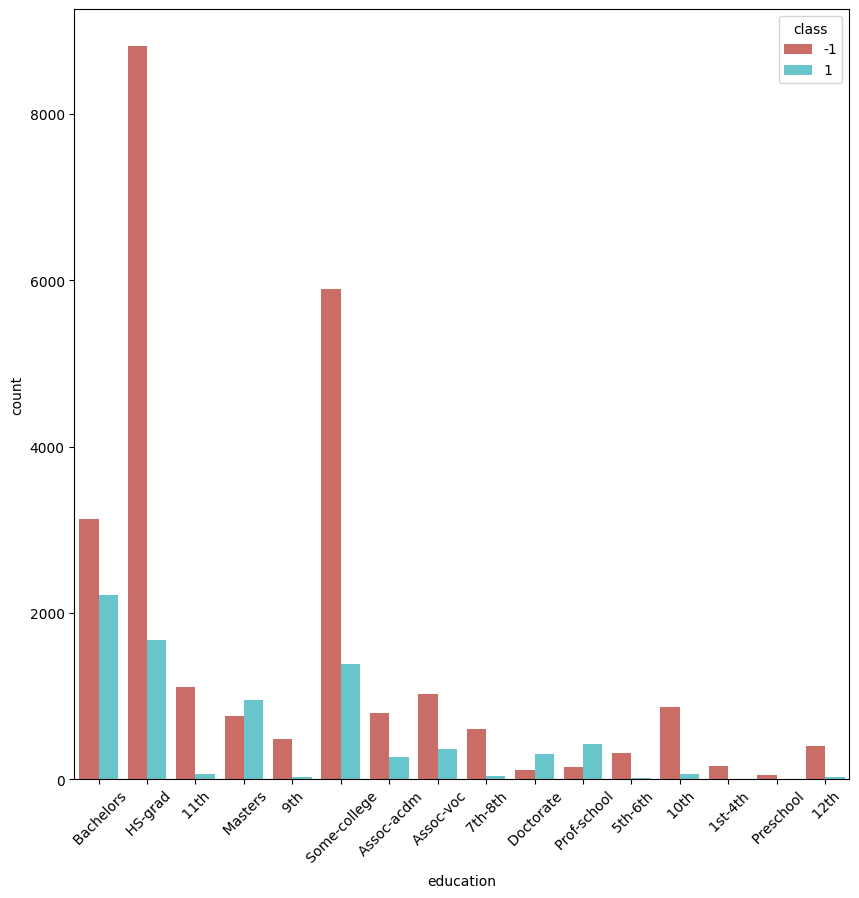

In [56]:
plt.figure(figsize=(10,10))
sns.countplot(x="education",hue="class",data=df,palette="hls")
plt.xticks(rotation=45)
plt.show()

In [57]:
status=df["marital-status"].value_counts(normalize=False).reset_index()

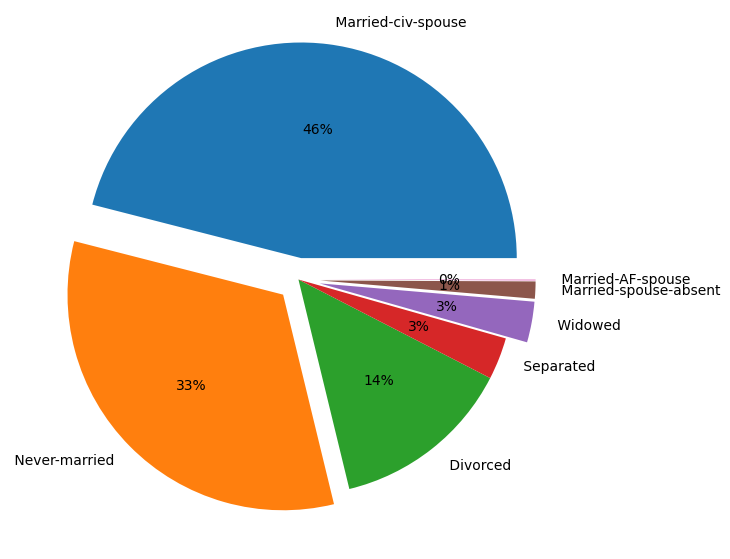

In [58]:
plt.figure(figsize=(7,7))
explode = [0.1, 0.1, 0, 0, 0.1,0.1,0.1]
plt.pie(data=status,x="marital-status",labels="index",autopct='%.0f%%',explode=explode)
plt.show()

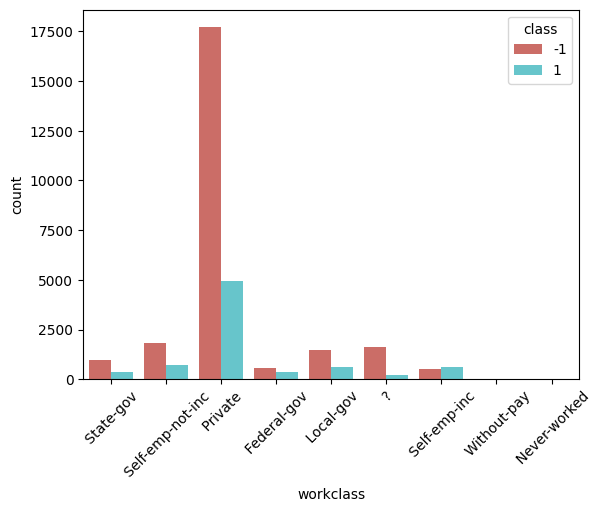

In [59]:
sns.countplot(x="workclass",data=df,hue="class",palette="hls")
plt.xticks(rotation=45)
plt.show()

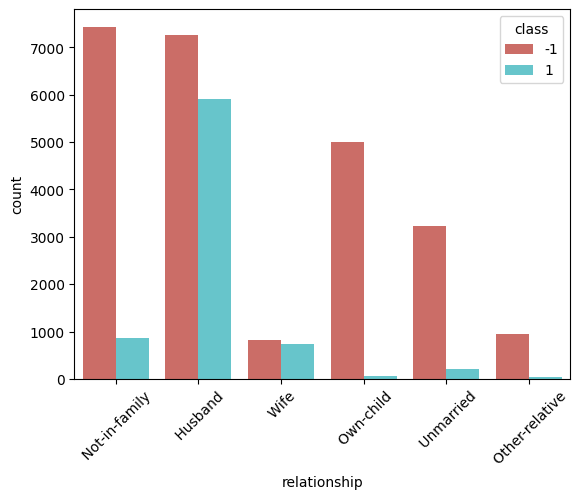

In [60]:
sns.countplot(x="relationship",data=df,hue="class",palette="hls")
plt.xticks(rotation=45)
plt.show()

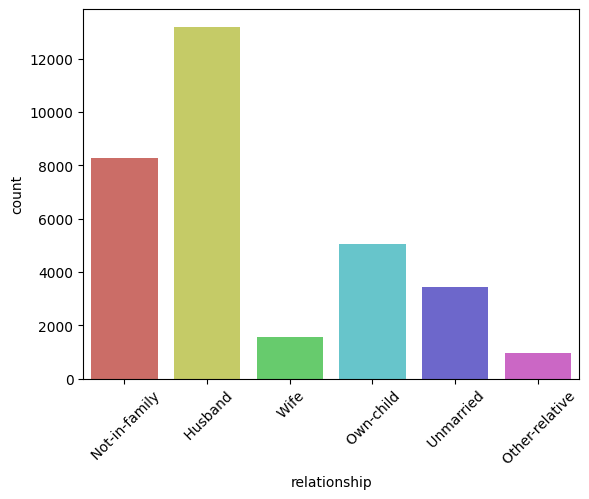

In [61]:
sns.countplot(x="relationship",data=df,palette="hls")
plt.xticks(rotation=45)
plt.show()

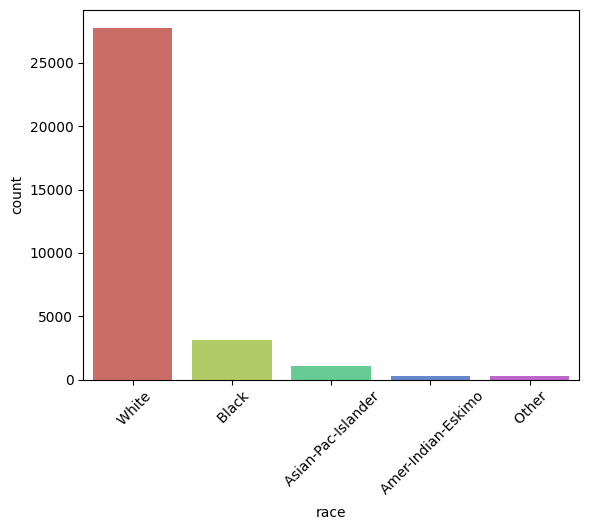

In [62]:
sns.countplot(x="race",data=df,palette="hls")
plt.xticks(rotation=45)
plt.show()

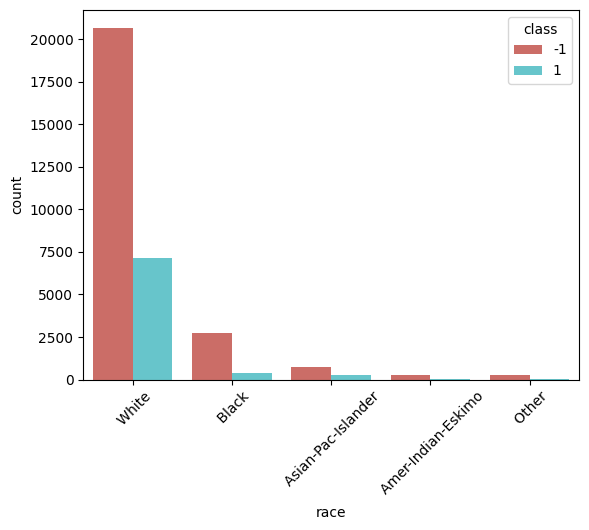

In [63]:
sns.countplot(x="race",data=df,hue="class",palette="hls")
plt.xticks(rotation=45)
plt.show()

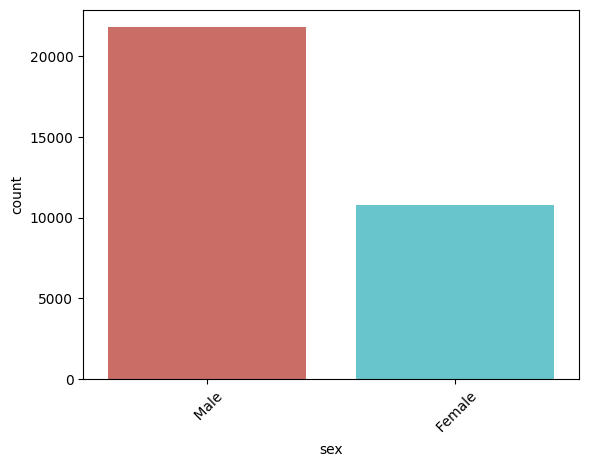

In [64]:
sns.countplot(x="sex",data=df,palette="hls")
plt.xticks(rotation=45)
plt.show()

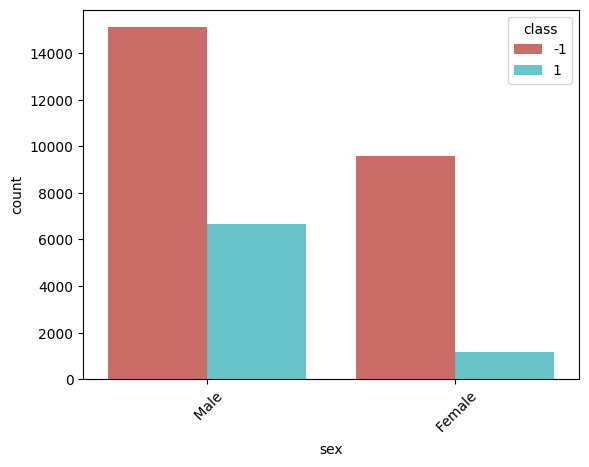

In [65]:
sns.countplot(x="sex",data=df,hue="class",palette="hls")
plt.xticks(rotation=45)
plt.show()

In [66]:
male=df[df["sex"]==" Male"]

In [67]:
female=df[df["sex"]==" Female"]

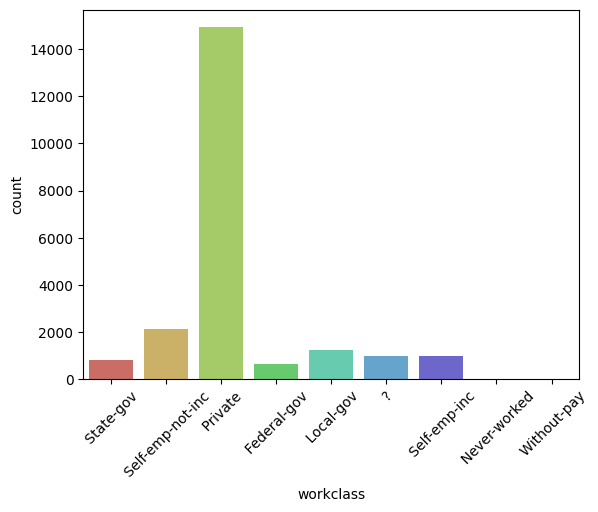

In [68]:
sns.countplot(x="workclass",data=male,palette="hls")
plt.xticks(rotation=45)
plt.show()

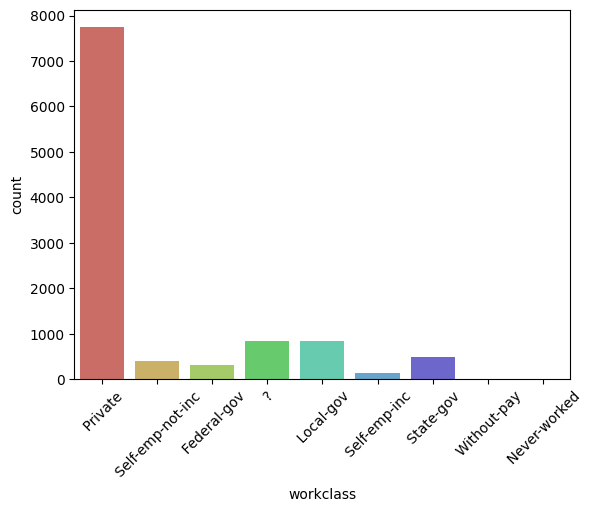

In [69]:
sns.countplot(x="workclass",data=female,palette="hls")
plt.xticks(rotation=45)
plt.show()

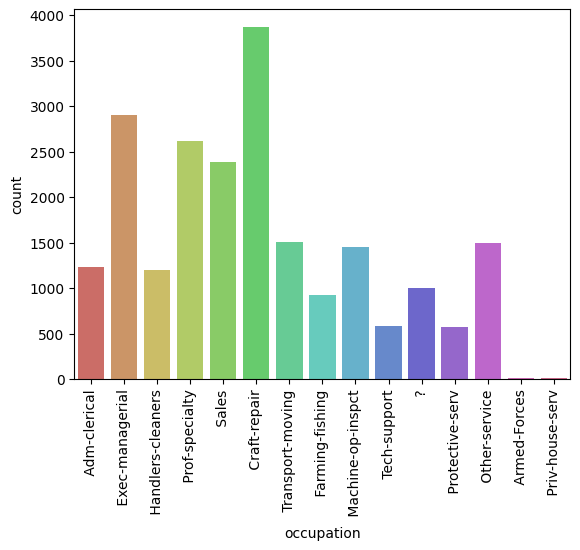

In [70]:
sns.countplot(x="occupation",data=male,palette="hls")
plt.xticks(rotation=90)
plt.show()

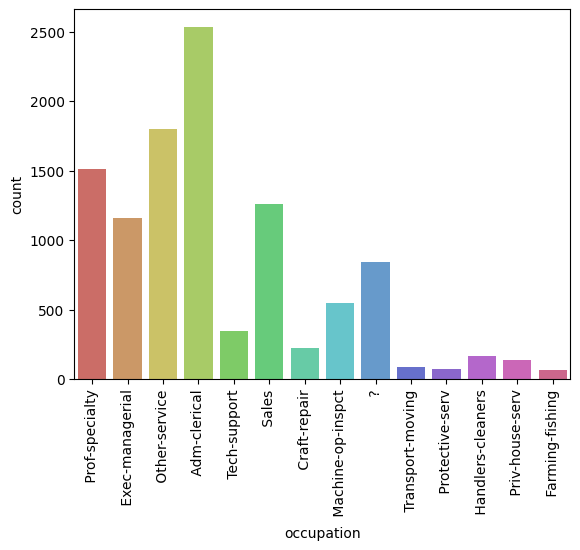

In [71]:
sns.countplot(x="occupation",data=female,palette="hls")
plt.xticks(rotation=90)
plt.show()

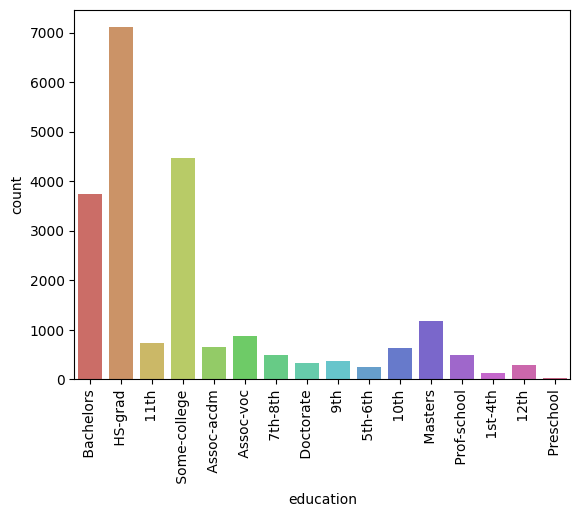

In [72]:
sns.countplot(x="education",data=male,palette="hls")
plt.xticks(rotation=90)
plt.show()

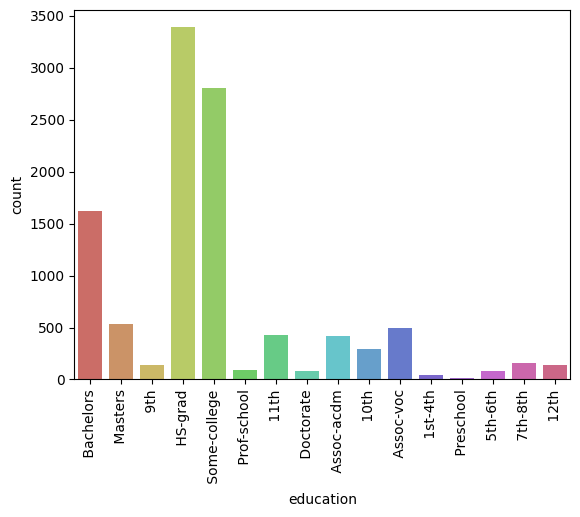

In [73]:
sns.countplot(x="education",data=female,palette="hls")
plt.xticks(rotation=90)
plt.show()

In [74]:
import os
print(os.environ['PATH'])

/home/shahabas/anaconda3/envs/jidoka_env/bin:/home/shahabas/anaconda3/bin:/home/shahabas/anaconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin


In [78]:
!export PATH=/Library/TeX/texbin:$PATH